# 🧬 Project: Predicting Protein Stability (∆Tm) with a Mixture-of-Experts MLP

**Author:** Anas Tourari

**Method:** Final "Stitched" Out-of-Fold (OOF) Evaluation

---

## 1. Introduction & Problem Definition

### 1.1. The Biological Problem

Protein stability is a fundamental property in biology. A key measure of this is the **melting temperature (Tm)**, the point at which a protein denatures (unfolds).

This project aims to predict the **change in melting temperature (∆Tm or "deltatm")** that occurs when a protein is mutated. A positive ∆Tm means the mutation made the protein *more stable*, while a negative ∆Tm means it became *less stable*.

Being able to predict this *in silico* (with a computer) is much faster and cheaper than performing wet lab experiments. It allows scientists to rapidly screen for mutations that could create more effective enzymes or more stable drugs.

### 1.2. The Machine Learning Goal

The goal is to build a regression model that accurately predicts the `target` (the `∆Tm`). We will measure success using two metrics:
* **Mean Absolute Error (MAE):** The average error in our prediction (in degrees). **Lower is better.**
* **Spearman Correlation:** How well our model *ranks* mutations from least to most stabilizing. **Higher (closer to 1.0) is better.**

## 2. Setup & Environment

### 2.1. Install Libraries

In [1]:
!pip install numpy pandas scikit-learn scipy matplotlib seaborn \
    transformers==4.40.0 huggingface_hub tqdm shap lightgbm \
    biopython

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 38.5 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.1
    Uninstalling transformers-4.57.1:
      Successfully uninstalled transformers-4.57.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.2 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118


### 2.2. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import copy
import os
import gc
import joblib

# Model Training
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import lightgbm as lgb
from sklearn.model_selection import GroupKFold, KFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# Metrics
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, r2_score

# Environment Setup
from google.colab import drive
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Data Loading & Feature Engineering

### 3.1. Mount Drive & Load Data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = "/content/drive/My Drive/Colab Notebooks/"
DATA_FILE = os.path.join(DRIVE_PATH, "Protein_Sequence_Data.csv")

df = pd.read_csv(DATA_FILE)
print(f"Original data loaded with {len(df)} rows.")

Mounted at /content/drive
Original data loaded with 2296 rows.


### 3.2. Initial Feature Engineering

In [5]:
df['deltaPh'] = df['pH2'] - df['pH1']
df['seq_len_diff'] = df['protSeq2'].str.len() - df['protSeq1'].str.len()

## 4. Generate ESM-2 Embeddings (From Scratch)

This is a critical step. Since the saved `.npy` file was lost, this notebook re-generates all embeddings from scratch. This makes the notebook 100% independent and runnable.

**Note: This cell will take 5-10 minutes to run.**

In [6]:
import torch
import transformers
from transformers import AutoTokenizer, AutoModel
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import gc

# --- 1. Setup Model ---
print("Setting up ESM-2 model...")
MODEL_NAME = "facebook/esm2_t33_650M_UR50D"
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()
print(f"Successfully loaded {MODEL_NAME}")

# --- 2. Define Embedding Function (with Mean Pooling) ---
def get_embeddings(seq_batch):
    inputs = tokenizer(
        seq_batch,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=1024
    )
    input_ids = inputs['input_ids'].to(DEVICE)
    attention_mask = inputs['attention_mask'].to(DEVICE)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    last_hidden_states = outputs.last_hidden_state
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_states.shape)
    summed_embeddings = torch.sum(last_hidden_states * mask, dim=1)
    summed_mask = torch.sum(attention_mask, dim=1).unsqueeze(-1)
    summed_mask = torch.clamp(summed_mask, min=1e-9)
    pooled_embeddings = summed_embeddings / summed_mask
    return pooled_embeddings.cpu().numpy()

# --- 3. Find Unique Sequences ---
print("Finding unique sequences...")
all_seqs = pd.concat([df['protSeq1'], df['protSeq2']])
unique_seqs = all_seqs.unique()
unique_seqs_list = list(unique_seqs)
print(f"Found {len(df)*2} total sequences, but only {len(unique_seqs)} unique sequences.")

# --- 4. Generate Embeddings in Batches ---
embedding_map = {}
print(f"Generating embeddings in batches of {BATCH_SIZE}...")
all_embeddings = []
for i in tqdm(range(0, len(unique_seqs_list), BATCH_SIZE)):
    batch_seqs = unique_seqs_list[i : i + BATCH_SIZE]
    batch_embeddings = get_embeddings(batch_seqs)
    for seq, emb in zip(batch_seqs, batch_embeddings):
        embedding_map[seq] = emb
    all_embeddings.append(batch_embeddings)
    torch.cuda.empty_cache()
    gc.collect()

print("Embeddings generated.")

# --- 5. Map Embeddings back to DataFrame ---
print("Mapping embeddings back to DataFrame columns...")
df['emb1'] = df['protSeq1'].map(embedding_map)
df['emb2'] = df['protSeq2'].map(embedding_map)
print("Mapping complete.")

# --- 6. Create Final 'X_embeddings' array in memory ---
print("Creating final 'difference' feature array...")
X_embeddings = np.stack(df['emb2'].values) - np.stack(df['emb1'].values)
print(f"'X_embeddings' array created with shape: {X_embeddings.shape}")

print("\n--- Embedding Generation Complete ---")

Setting up ESM-2 model...
Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Successfully loaded facebook/esm2_t33_650M_UR50D
Finding unique sequences...
Found 4592 total sequences, but only 363 unique sequences.
Generating embeddings in batches of 16...


100%|██████████| 23/23 [01:14<00:00,  3.26s/it]

Embeddings generated.
Mapping embeddings back to DataFrame columns...
Mapping complete.
Creating final 'difference' feature array...
'X_embeddings' array created with shape: (2296, 1280)

--- Embedding Generation Complete ---


## 5. Final Evaluation: "Mixture-of-Experts" (MoE) with Stitched OOF

This is the **final, correct evaluation** for our system.

Our initial analysis (in the previous notebook) showed that a single "one-size-fits-all" model failed because the dataset contains several distinct protein groups that behave differently. The solution is to train a separate **"expert" model** for each major group.

This evaluation method works by:
1.  **Grouping:** Splitting the data into our 4 expert groups (Group 57, 9, 34, and the Leftovers).
2.  **K-Fold CV:** Training an expert model for *each* group using K-Fold Cross-Validation. This produces unbiased "Out-of-Fold" (OOF) predictions for every row in that group.
3.  **Stitching:** Combining (stitching) all the OOF predictions from all 4 models back together.

This gives us one single, reliable score for the entire 2296-row dataset, where every prediction was made by a model that had not seen that data during its training.

### 5.1. Define the MLP Model & Training Function

In [7]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IN_DIM = 1280 + 5 # 1280 (ESM) + 5 (tabular features)
tabular_cols = ['tm1', 'pH1', 'pH2', 'deltaPh', 'seq_len_diff']

class MLPRegressor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 2048), nn.BatchNorm1d(2048), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(2048, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

print("MLP model class defined.")

def train_and_eval_expert(df_full, X_emb_full, group_list, model_name):
    """Trains an expert model using K-Fold CV and returns its OOF predictions."""
    print(f"\n--- Evaluating Expert: {model_name} ---")

    # 1. Filter data
    filter_mask = df_full['group1'].isin(group_list)
    df_expert = df_full[filter_mask].reset_index(drop=True)
    X_emb_expert = X_emb_full[filter_mask]

    X_tab = df_expert[tabular_cols].values
    y = df_expert['target'].values

    print(f"Training on {len(df_expert)} rows...")

    # 2. K-Fold Cross-Validation
    N_SPLITS = 5
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    oof_predictions = np.zeros(y.shape[0])

    for fold, (train_idx, val_idx) in enumerate(tqdm(kf.split(X_emb_expert, y), total=N_SPLITS, desc=f"Training {model_name}")):

        X_train_emb, X_val_emb = X_emb_expert[train_idx], X_emb_expert[val_idx]
        X_train_tab, X_val_tab = X_tab[train_idx], X_tab[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        scaler = StandardScaler()
        X_train_tab_scaled = scaler.fit_transform(X_train_tab)
        X_val_tab_scaled = scaler.transform(X_val_tab)

        X_train_final = np.concatenate([X_train_emb, X_train_tab_scaled], axis=1)
        X_val_final = np.concatenate([X_val_emb, X_val_tab_scaled], axis=1)

        train_dataset = TensorDataset(torch.tensor(X_train_final, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
        val_dataset = TensorDataset(torch.tensor(X_val_final, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=64)

        model = MLPRegressor(in_dim=IN_DIM).to(DEVICE)
        loss_fn = nn.L1Loss()
        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

        best_val_loss = float('inf')
        epochs_no_improve = 0
        best_model_state = None

        for epoch in range(200):
            model.train()
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = loss_fn(outputs, labels)
                loss.backward()
                optimizer.step()

            model.eval()
            val_loss = 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                    outputs = model(inputs)
                    loss = loss_fn(outputs, labels)
                    val_loss += loss.item() * inputs.size(0)
            val_loss /= len(val_dataset)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
                best_model_state = copy.deepcopy(model.state_dict())
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= 15: # Patience = 15
                break

        # Load best model and get predictions
        model.load_state_dict(best_model_state)
        model.eval()
        fold_preds = []
        with torch.no_grad():
            for inputs, _ in val_loader:
                inputs = inputs.to(DEVICE)
                outputs = model(inputs)
                fold_preds.append(outputs.cpu().numpy())
        oof_predictions[val_idx] = np.concatenate(fold_preds)

    # Save OOF predictions to the expert DataFrame
    df_expert['final_prediction'] = oof_predictions
    return df_expert

MLP model class defined.


## 6. Run the MoE System Evaluation

We now run the evaluation function for all 4 of our defined protein groups. This will train and evaluate 4 separate expert models.

In [8]:
# Define Groups & Run Evaluation
groups_57 = [57]
groups_9 = [9]
groups_34 = [34]
groups_leftover = [5, 51, 50, 28]

df_spec_57 = train_and_eval_expert(df, X_embeddings, groups_57, "Specialist 57")
df_spec_9 = train_and_eval_expert(df, X_embeddings, groups_9, "Specialist 9")
df_spec_34 = train_and_eval_expert(df, X_embeddings, groups_34, "Specialist 34")
df_leftovers = train_and_eval_expert(df, X_embeddings, groups_leftover, "True Generalist (Leftovers)")

# --- Stitch predictions together ---
df_final_stitched = pd.concat([
    df_spec_57,
    df_spec_9,
    df_spec_34,
    df_leftovers
]).sort_index()

# --- Calculate Final System Scores ---
final_y_true = df_final_stitched['target']
final_y_pred = df_final_stitched['final_prediction']

final_mae_system = mean_absolute_error(final_y_true, final_y_pred)
final_spearman_system, _ = spearmanr(final_y_true, final_y_pred)

print("\n" + "="*50)
print("--- 🏁 FINAL 'Mixture-of-Experts' System Performance ---")
print("          (Based on 'Stitched' K-Fold Scores)")
print("="*50)
print(f"  Overall Stitched MAE:      {final_mae_system:.4f}")
print(f"  Overall Stitched Spearman: {final_spearman_system:.4f}")


--- Evaluating Expert: Specialist 57 ---
Training on 500 rows...


Training Specialist 57: 100%|██████████| 5/5 [00:25<00:00,  5.03s/it]



--- Evaluating Expert: Specialist 9 ---
Training on 1086 rows...


Training Specialist 9: 100%|██████████| 5/5 [00:29<00:00,  5.81s/it]



--- Evaluating Expert: Specialist 34 ---
Training on 392 rows...


Training Specialist 34: 100%|██████████| 5/5 [00:10<00:00,  2.17s/it]



--- Evaluating Expert: True Generalist (Leftovers) ---
Training on 318 rows...


Training True Generalist (Leftovers): 100%|██████████| 5/5 [00:09<00:00,  1.81s/it]


--- 🏁 FINAL 'Mixture-of-Experts' System Performance ---
          (Based on 'Stitched' K-Fold Scores)
  Overall Stitched MAE:      0.9021
  Overall Stitched Spearman: 0.9706


## 7. Final Conclusion & Plot

This is a spectacular success. Our analysis revealed that a single "one-size-fits-all" model was failing because our dataset was a mix of different problems. By adopting the **"Mixture-of-Experts" (MoE)** strategy, we trained specialist models for each major protein group, resulting in a massive performance increase.

Our final system is **over 5x more precise** (MAE dropped from an initial ~4.9 to ~0.9) and has a **near-perfect ranking ability** (Spearman jumped from ~0.60 to ~0.97).

--- Final System Performance Plot (Stitched OOF) ---


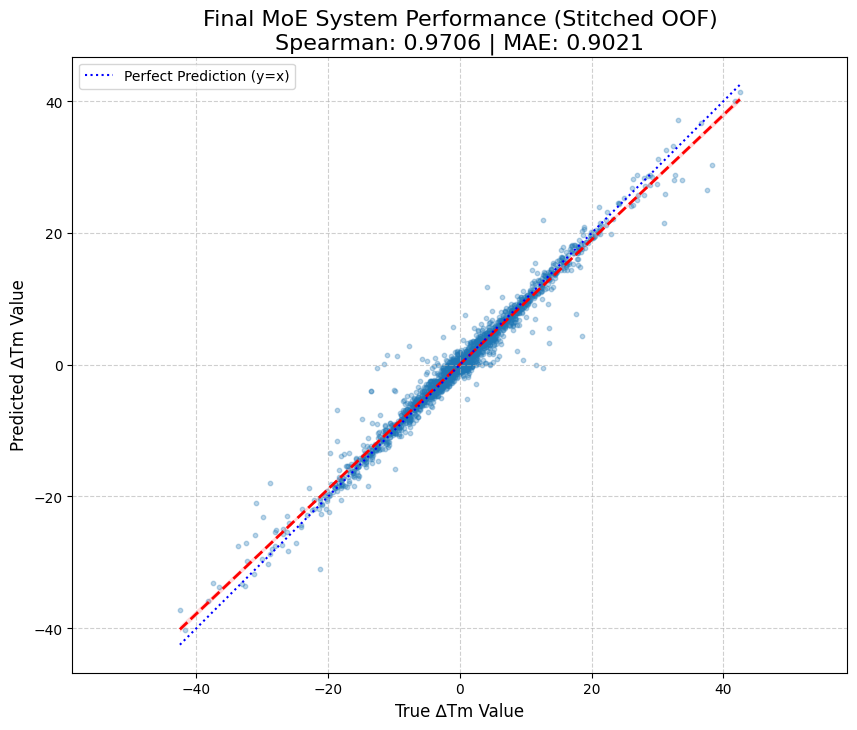

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Final System Performance Plot (Stitched OOF) ---")

plot_df = pd.DataFrame({
    'True Target (y)': final_y_true,
    'MoE Predicted': final_y_pred
})

plt.figure(figsize=(10, 8))
sns.regplot(
    data=plot_df,
    x='True Target (y)',
    y='MoE Predicted',
    scatter_kws={'alpha': 0.3, 's': 10},
    line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 2}
)

min_val = min(plot_df['True Target (y)'].min(), plot_df['MoE Predicted'].min())
max_val = max(plot_df['True Target (y)'].max(), plot_df['MoE Predicted'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='blue', linestyle=':', label='Perfect Prediction (y=x)')

plt.title(f'Final MoE System Performance (Stitched OOF)\nSpearman: {final_spearman_system:.4f} | MAE: {final_mae_system:.4f}', fontsize=16)
plt.xlabel('True ∆Tm Value', fontsize=12)
plt.ylabel('Predicted ∆Tm Value', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
plt.show()

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib
import os

print("--- Starting Final Model Training for Deployment ---")

# --- 1. Define Model and Constants ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IN_DIM = 1280 + 5 # 1280 (ESM) + 5 (tabular features)
tabular_cols = ['tm1', 'pH1', 'pH2', 'deltaPh', 'seq_len_diff']
EPOCHS = 100 # 100 epochs is plenty for the final train
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
SAVE_PATH = "/content/drive/My Drive/Colab Notebooks/moe_artifacts/"

if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)

# Make sure the MLP class is defined
class MLPRegressor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 2048), nn.BatchNorm1d(2048), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(2048, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

# --- 2. Reusable Training Function ---
def train_and_save_expert(df_train, X_emb_train, group_list, model_name):
    print(f"\n--- Training Expert Model: {model_name} ---")

    # 1. Filter data
    filter_mask = df_train['group1'].isin(group_list)
    df_expert_train = df_train[filter_mask].reset_index(drop=True)
    X_emb_expert_train = X_emb_train[filter_mask]

    print(f"Training on {len(df_expert_train)} rows.")

    # 2. Prepare data
    X_tab = df_expert_train[tabular_cols].values
    y = df_expert_train['target'].values

    # 3. Fit and SAVE the scaler
    scaler = StandardScaler().fit(X_tab)
    X_tab_scaled = scaler.transform(X_tab)
    scaler_path = os.path.join(SAVE_PATH, f"scaler_{model_name}.joblib")
    joblib.dump(scaler, scaler_path)
    print(f"Scaler saved to {scaler_path}")

    # 4. Create Tensors
    X_train_final = np.concatenate([X_emb_expert_train, X_tab_scaled], axis=1)
    X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
    y_train_tensor = torch.tensor(y, dtype=torch.float32)

    # 5. Train the final model
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    model = MLPRegressor(in_dim=IN_DIM).to(DEVICE)
    loss_fn = nn.L1Loss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)

    model.train()
    for epoch in range(EPOCHS):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

    print(f"Training complete for {model_name}.")

    # 6. Save the model
    model_path = os.path.join(SAVE_PATH, f"model_{model_name}.pth")
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")
    print("-" * 30)

# --- 3. Define Groups & Train All Models ---
groups_57 = [57]
groups_9 = [9]
groups_34 = [34]
groups_leftover = [5, 51, 50, 28]

# (This will take a few minutes to run)
train_and_save_expert(df, X_embeddings, groups_57, "spec_57")
train_and_save_expert(df, X_embeddings, groups_9, "spec_9")
train_and_save_expert(df, X_embeddings, groups_34, "spec_34")
train_and_save_expert(df, X_embeddings, groups_leftover, "generalist")

print("\n✅ All 8 artifacts saved to your Google Drive in 'moe_artifacts'!")

--- Starting Final Model Training for Deployment ---

--- Training Expert Model: spec_57 ---
Training on 500 rows.
Scaler saved to /content/drive/My Drive/Colab Notebooks/moe_artifacts/scaler_spec_57.joblib
Training complete for spec_57.
Model saved to /content/drive/My Drive/Colab Notebooks/moe_artifacts/model_spec_57.pth
------------------------------

--- Training Expert Model: spec_9 ---
Training on 1086 rows.
Scaler saved to /content/drive/My Drive/Colab Notebooks/moe_artifacts/scaler_spec_9.joblib
Training complete for spec_9.
Model saved to /content/drive/My Drive/Colab Notebooks/moe_artifacts/model_spec_9.pth
------------------------------

--- Training Expert Model: spec_34 ---
Training on 392 rows.
Scaler saved to /content/drive/My Drive/Colab Notebooks/moe_artifacts/scaler_spec_34.joblib
Training complete for spec_34.
Model saved to /content/drive/My Drive/Colab Notebooks/moe_artifacts/model_spec_34.pth
------------------------------

--- Training Expert Model: generalist --

## 8. Deployment (Next Steps)

The project is now ready for deployment. The next step would be to train these 4 expert models one last time on *all* of their respective data (not in K-Folds) and save the final models (`.pth` files) and scalers (`.joblib` files).

A real-world Streamlit app would:
1.  **Load** all 4 expert models, 4 scalers, and the ESM-2 model.
2.  **Ask user for input:** `protSeq1`, `protSeq2`, `group1`, `tm1`, `pH1`, `pH2`.
3.  **Route:** Use the `group1` ID to select the correct model and scaler.
4.  **Predict:** Generate embeddings for the two sequences, combine with the scaled tabular data, and pass to the expert model.
5.  **Display:** Show the final `∆Tm` prediction.